In [40]:
#importing libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [41]:
# Load air quality, health, and weather datasets

air = pd.read_csv("london_air_quality_2025.csv")
health = pd.read_csv("london_health_2025.csv")
weather = pd.read_csv("london_weather_2025.csv")

# Display first few rows to understand structure
print(air.head())
print(health.head())
print(weather.head())

         date  PM2.5   PM10     NO2     O3
0  2025-01-01  45.59  82.36  102.39  66.88
1  2025-01-02  48.06  15.20  112.93  26.08
2  2025-01-03  49.11  76.48   77.81  72.26
3  2025-01-04  38.26  41.34   41.87  44.23
4  2025-01-05  20.41  46.29   61.26  16.64
         date  asthma_admissions  respiratory_cases
0  2025-01-01                 38                109
1  2025-01-02                 14                 66
2  2025-01-03                  5                 96
3  2025-01-04                 31                 48
4  2025-01-05                 23                 76
         date  temperature_C  rainfall_mm  humidity_%
0  2025-01-01           6.04         5.06       41.36
1  2025-01-02           1.24         5.06       84.00
2  2025-01-03           3.75         8.36       58.27
3  2025-01-04           9.41         5.76       53.88
4  2025-01-05          11.34         1.72       91.09


DATA CLEANING & PREPROCESSING

In [42]:
# Convert 'date' column to datetime format for all datasets
air['date'] = pd.to_datetime(air['date'])
health['date'] = pd.to_datetime(health['date'])
weather['date'] = pd.to_datetime(weather['date'])


# Handle missing values using forward fill method
# (fills missing values with previous valid observation)
air.ffill(inplace=True)
health.ffill(inplace=True)
weather.ffill(inplace=True)

MERGE DATASETS

In [43]:
# Merge air quality and weather data on 'date'
df = air.merge(weather, on='date')

# Merge the result with health data
df = df.merge(health, on='date')

# TIME-SERIES FEATURES
# Lag features (previous day effect)
df['PM2.5_lag1'] = df['PM2.5'].shift(1)
df['NO2_lag1'] = df['NO2'].shift(1)
df['asthma_lag1'] = df['asthma_admissions'].shift(1)

# Rolling average (7-day smoothing)
df['PM2.5_rolling'] = df['PM2.5'].rolling(7).mean()

# Drop NaN values created by lag/rolling
df.dropna(inplace=True)

# Display merged dataset
print(df.head())

         date  PM2.5   PM10     NO2     O3  temperature_C  rainfall_mm  \
6  2025-01-07  53.09  34.76   72.05  35.59           8.74         5.93   
7  2025-01-08  12.68  31.75  102.22  73.58          10.21         2.32   
8  2025-01-09  46.15  69.12   92.22  27.00           2.60         8.07   
9  2025-01-10   7.00  76.15   43.99  74.65           9.61        16.45   
10 2025-01-11  16.14  42.74   35.79  29.83          22.89        16.08   

    humidity_%  asthma_admissions  respiratory_cases  PM2.5_lag1  NO2_lag1  \
6        48.03                 38                 88       23.15     95.64   
7        61.69                 36                 74       53.09     72.05   
8        77.64                 11                 93       12.68    102.22   
9        75.63                 18                 81       46.15     92.22   
10       84.04                 37                 98        7.00     43.99   

    asthma_lag1  PM2.5_rolling  
6          13.0      39.667143  
7          38.0     

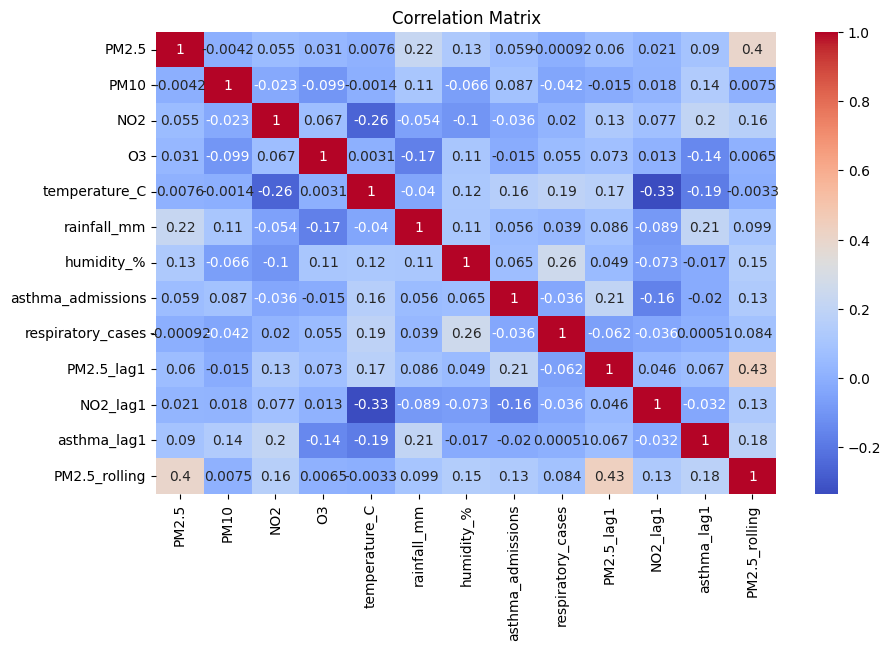

In [44]:
# Correlation heatmap (only numerical columns)
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

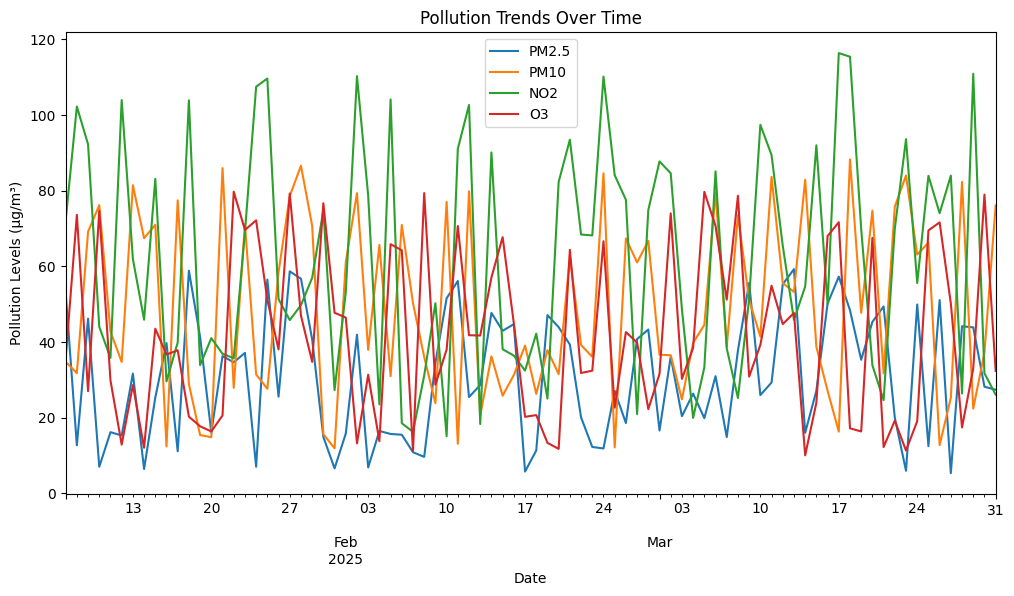

In [45]:
# Plot pollution trends over time
df.set_index('date')[['PM2.5','PM10','NO2','O3']].plot(figsize=(12,6))
plt.title("Pollution Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Pollution Levels (µg/m³)")
plt.show()

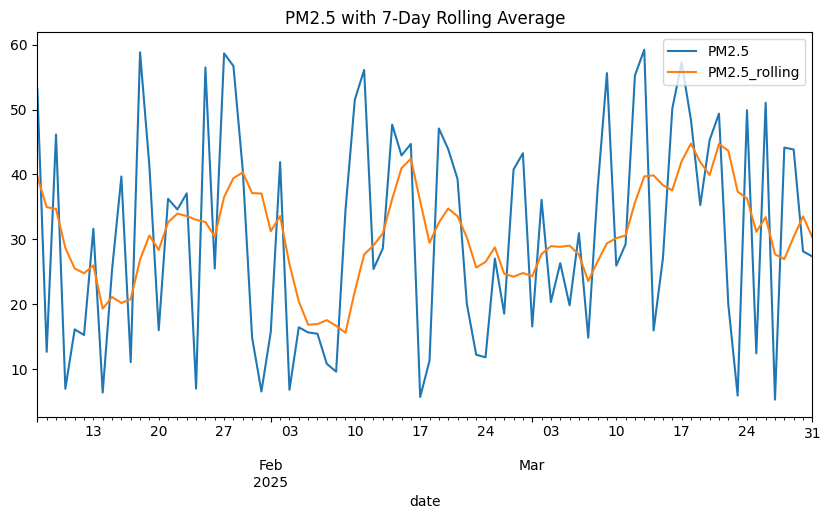

In [46]:
# ADVANCED EDA 

df.set_index('date')[['PM2.5','PM2.5_rolling']].plot(figsize=(10,5))
plt.title("PM2.5 with 7-Day Rolling Average")
plt.show()

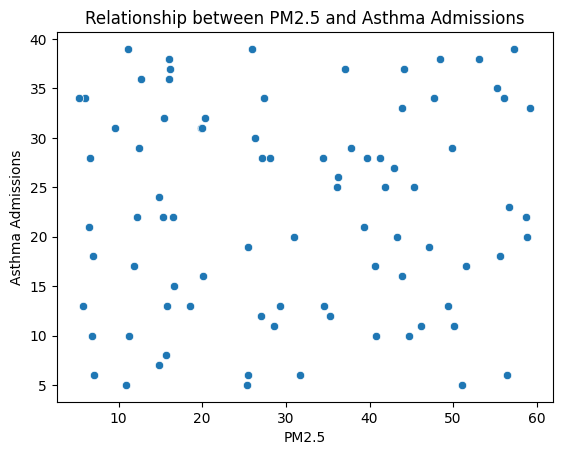

In [47]:
# Scatter plot: PM2.5 vs Asthma Admissions

sns.scatterplot(x='PM2.5', y='asthma_admissions', data=df)
plt.title("Relationship between PM2.5 and Asthma Admissions")
plt.xlabel("PM2.5")
plt.ylabel("Asthma Admissions")
plt.show()

In [49]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Create stats table
stats = pd.DataFrame({
    'Mean': numeric_df.mean(),
    'Std Dev': numeric_df.std(),
    'Variance': numeric_df.var(),
    'Min': numeric_df.min(),
    'Max': numeric_df.max(),
    'Skewness': numeric_df.skew()
})

# Round values
stats = stats.round(2)

# Reset index for clean table
stats = stats.reset_index()
stats.rename(columns={'index': 'Variable'}, inplace=True)

# Print simple table
print(stats)

             Variable   Mean  Std Dev  Variance    Min     Max  Skewness
0               PM2.5  30.78    16.59    275.13   5.32   59.23      0.10
1                PM10  49.26    23.58    555.87  11.89   88.25      0.09
2                 NO2  61.85    29.64    878.74  15.08  116.34      0.18
3                  O3  42.23    22.27    496.10  10.02   79.71      0.28
4       temperature_C  11.94     7.51     56.47   0.09   24.58      0.14
5         rainfall_mm   9.71     6.34     40.16   0.16   19.84      0.15
6          humidity_%  67.43    16.67    277.75  41.19   94.45     -0.07
7   asthma_admissions  22.54    10.38    107.82   5.00   39.00     -0.08
8   respiratory_cases  69.10    26.94    725.92  20.00  118.00     -0.35
9          PM2.5_lag1  30.73    16.60    275.69   5.32   59.23      0.11
10           NO2_lag1  62.68    29.60    876.39  15.08  116.34      0.14
11        asthma_lag1  22.29    10.36    107.27   5.00   39.00     -0.03
12      PM2.5_rolling  30.79     7.03     49.42  15

FEATURE SELECTION

In [31]:
# Select input features (independent variables)
X = df[['PM2.5', 'PM10', 'NO2', 'O3', 'temperature_C', 'rainfall_mm']]

# Target variable (dependent variable)
y = df['asthma_admissions']

TRAIN-TEST SPLIT

In [32]:
# TIME-SERIES SPLIT 
split = int(len(df)*0.8)

X = df[['PM2.5', 'PM10', 'NO2', 'O3', 'temperature_C', 'rainfall_mm',
        'PM2.5_lag1','NO2_lag1','asthma_lag1','PM2.5_rolling']]

y = df['asthma_admissions']

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

MODEL 1: LINEAR REGRESSION

In [33]:
# Linear Regression model
# FEATURE SCALING 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()

# Train the model
lr.fit(X_train_scaled, y_train)


# Predict on test data
y_pred_lr = lr.predict(X_test_scaled)


# Evaluate performance
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))

Linear Regression R2: -0.5391616653909694
MSE: 163.77958316298648


MODEL 2: RANDOM FOREST

In [34]:
# Create Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf.predict(X_test)

# Evaluate performance
print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))

Random Forest R2: -0.4135896364464098
MSE: 150.41767647058822


In [35]:
# CROSS VALIDATION 
from sklearn.model_selection import cross_val_score

from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(rf, X, y, cv=tscv, scoring='r2')

print("Random Forest CV R2:", cv_scores.mean())

Random Forest CV R2: -0.643952243839457


MODEL COMPARISON TABLE

In [37]:
# Linear Regression Metrics
lr_r2 = r2_score(y_test, y_pred_lr)
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)

#  Random Forest Metrics 
rf_r2 = r2_score(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)

# Cross Validation (5-fold) 
lr_cv = cross_val_score(lr, X, y, cv=5, scoring='r2').mean()
rf_cv = cross_val_score(rf, X, y, cv=5, scoring='r2').mean()

#  Create Results Table 
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2 Score': [lr_r2, rf_r2],
    'MSE': [lr_mse, rf_mse],
    'RMSE': [lr_rmse, rf_rmse],
    'CV R2 (5-fold)': [lr_cv, rf_cv]
})

print(results)

               Model  R2 Score         MSE       RMSE  CV R2 (5-fold)
0  Linear Regression -0.539162  163.779583  12.797640       -0.496300
1      Random Forest -0.413590  150.417676  12.264488       -0.376436


FEATURE IMPORTANCE (RANDOM FOREST)

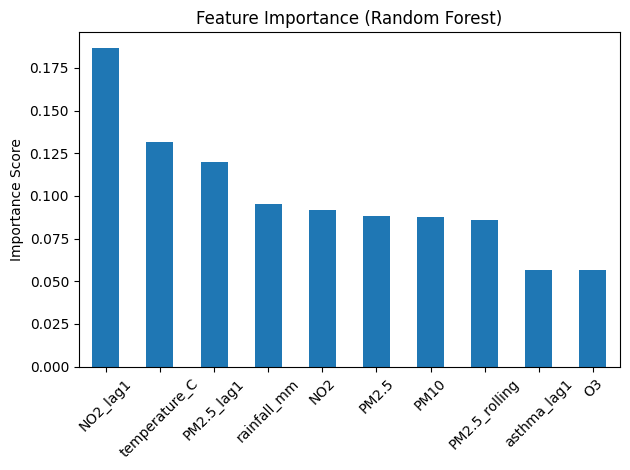

In [11]:
# Extract feature importance scores
importance = rf.feature_importances_

# Convert to pandas series
feat_imp = pd.Series(importance, index=X.columns)

# Plot feature importance
feat_imp.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ACTUAL VS PREDICTED PLOT

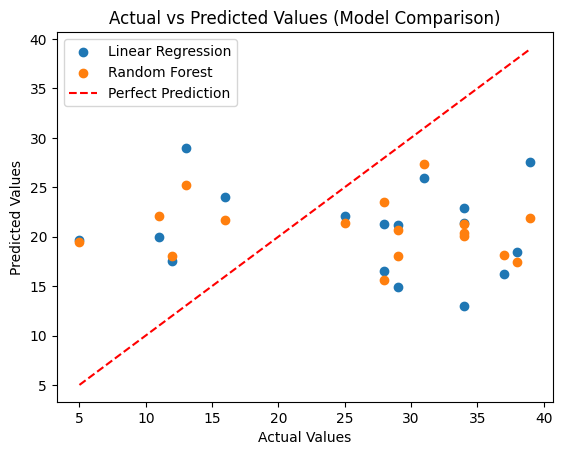

In [38]:
# Scatter plot comparing actual vs predicted values
# Linear Regression points
plt.figure()

plt.scatter(y_test, y_pred_lr, label="Linear Regression")

# Random Forest points
plt.scatter(y_test, y_pred_rf, label="Random Forest")

# Ideal prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', label="Perfect Prediction")

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (Model Comparison)")
plt.legend()

plt.show()

In [13]:
#Feature Importance Values
print("Feature Importance:")
print(feat_imp.sort_values(ascending=False))

Feature Importance:
NO2_lag1         0.186548
temperature_C    0.131454
PM2.5_lag1       0.120120
rainfall_mm      0.095354
NO2              0.091603
PM2.5            0.088202
PM10             0.087889
PM2.5_rolling    0.085795
asthma_lag1      0.056587
O3               0.056450
dtype: float64
